In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("seedtype_data.csv")

In [3]:
df.head()

,Area,Perimeter,Kernel_len,Kernel_width,Kernelgroove_len,Type
0,12.76,13.38,5.073,3.155,4.830,0.0
1,12.13,13.73,5.394,3.745,5.220,0.0
2,14.86,14.67,NaN,3.258,5.351,0.0
3,15.69,14.75,5.527,3.514,5.046,0.0
4,19.94,16.92,6.675,3.763,6.550,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Area              199 non-null    float64
 1   Perimeter         199 non-null    float64
 2   Kernel_len        193 non-null    float64
 3   Kernel_width      199 non-null    float64
 4   Kernelgroove_len  199 non-null    float64
 5   Type              199 non-null    float64
dtypes: float64(6)
memory usage: 9.6 KB


In [5]:
# 202 rows, 6 Columns
# All the variables in the dataset are numerical
# Type is the target variable
# No need of encoding

In [6]:
# Check null values
df.isnull().sum()

Area                3
Perimeter           3
Kernel_len          9
Kernel_width        3
Kernelgroove_len    3
Type                3
dtype: int64

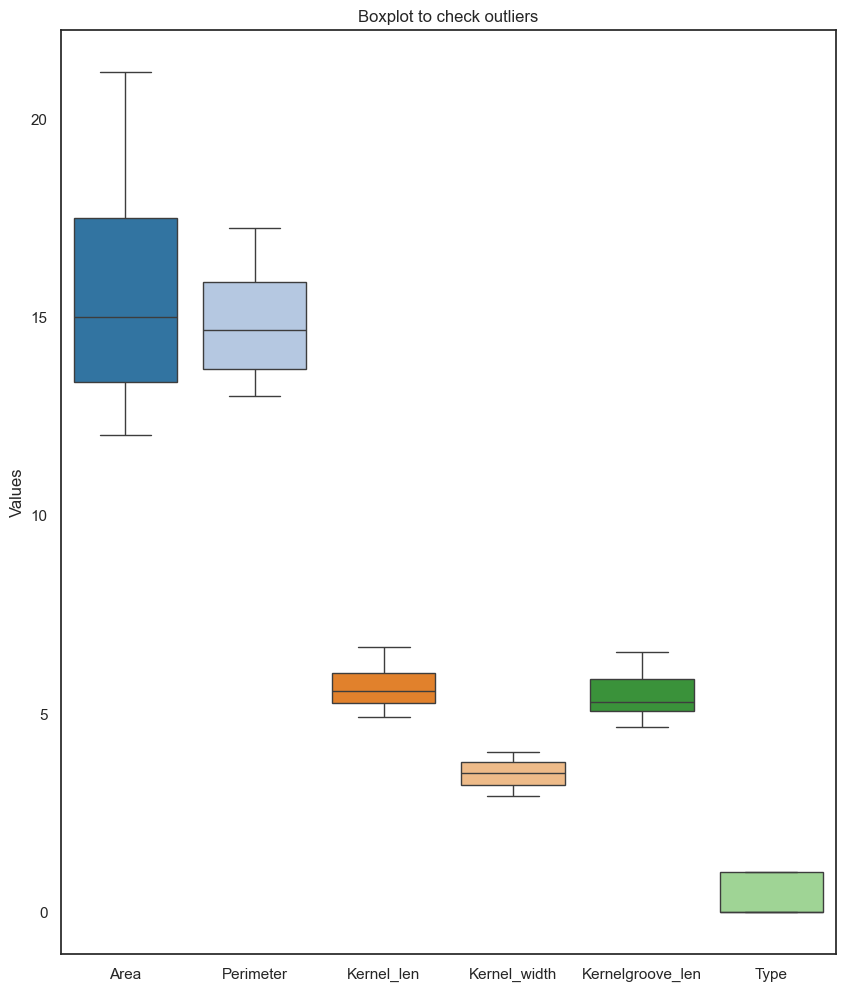

In [7]:
sns.set(style='white')
plt.figure(figsize=(10,12))
sns.boxplot(data=df, palette='tab20')
plt.title("Boxplot to check outliers")
plt.ylabel("Values")
plt.show()

In [8]:
# There are no outliers, therefore we can use the mean for imputing the missing values.

In [9]:
# Impute missing values
for col in df.columns:
    df[col] =  df[col].fillna(df[col].mean())

In [10]:
# Descriptive Statistics
df.describe()

,Area,Perimeter,Kernel_len,Kernel_width,Kernelgroove_len,Type
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,15.476533,14.792261,5.651036,3.471643,5.445779,0.356784
std,2.485384,1.201175,0.435219,0.303340,0.476254,0.476661
min,12.010000,13.010000,4.899000,2.911000,4.649000,0.000000
25%,13.352500,13.715000,5.282000,3.201000,5.063000,0.000000
50%,15.020000,14.700000,5.585000,3.478000,5.303000,0.000000
75%,17.412500,15.875000,5.980750,3.761000,5.879000,1.000000
max,21.180000,17.250000,6.675000,4.033000,6.550000,1.000000


In [11]:
# Upon comparing the values of different variables there is not huge difference.
# Therefore scaling is not needed.

In [20]:
# Preapre features & target variable

X = df.drop('Type',axis=1)

y = df['Type'].astype(int)

In [21]:
# Check null values post imputing them
df.isnull().sum()

Area                0
Perimeter           0
Kernel_len          0
Kernel_width        0
Kernelgroove_len    0
Type                0
dtype: int64

In [22]:
X.head()

,Area,Perimeter,Kernel_len,Kernel_width,Kernelgroove_len
0,12.76,13.38,5.073000,3.155,4.830
1,12.13,13.73,5.394000,3.745,5.220
2,14.86,14.67,5.651036,3.258,5.351
3,15.69,14.75,5.527000,3.514,5.046
4,19.94,16.92,6.675000,3.763,6.550


In [23]:
y.head()

0    0
1    0
2    0
3    0
4    1
Name: Type, dtype: int64

In [25]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Descision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

In [44]:
# Evaluating the model
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score


In [45]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        25
           1       0.88      0.94      0.91        16

    accuracy                           0.93        41
   macro avg       0.92      0.93      0.92        41
weighted avg       0.93      0.93      0.93        41



Confusion_Matrix:


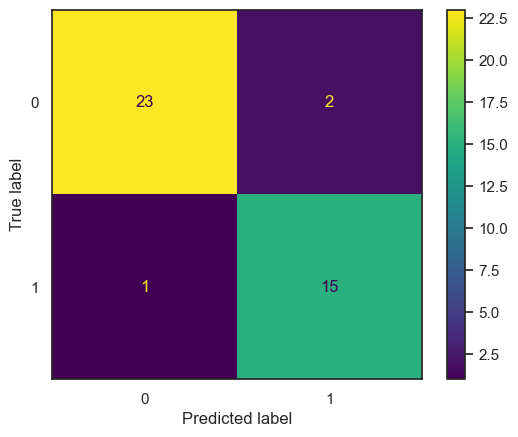

In [46]:
print("Confusion_Matrix:")
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

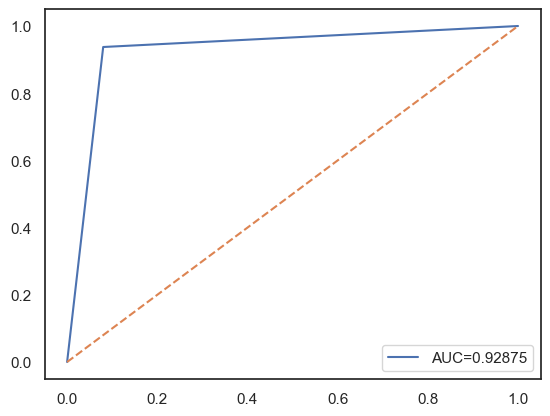

In [50]:
# AUC ROC Curve
# Finding TPR & FPR
y_proba = dt.predict_proba(X_test)[:,1]
tpr, fpr, threshold = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# Plot the AUC ROC Curve
plt.plot(tpr, fpr, label=f'AUC={auc_score}')
plt.plot([0,1],[0,1], linestyle='--')
plt.legend()
plt.show()

In [52]:
# Hyperparemeter Tunning
dt2 = DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=42)

In [55]:
dt2.fit(X_train,y_train)

y2_pred = dt2.predict(X_test)

print("Classification Report post Hyperparameter Tunning:")
print(classification_report(y_test,y2_pred))

Classification Report post Hyperparameter Tunning:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        25
           1       0.89      1.00      0.94        16

    accuracy                           0.95        41
   macro avg       0.94      0.96      0.95        41
weighted avg       0.96      0.95      0.95        41



In [56]:
# Upon Hyperparameter Tunning the model accuracy has improved

In [60]:
# Random Forest Classifier (Bagging)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=2, random_state=42)

rf.fit(X_train,y_train)

y3_pred = rf.predict(X_test)

print("Classification Report for Random Forest:")
print(classification_report(y_test, y3_pred))

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        25
           1       0.94      1.00      0.97        16

    accuracy                           0.98        41
   macro avg       0.97      0.98      0.97        41
weighted avg       0.98      0.98      0.98        41



In [62]:
# AdaBoost
from sklearn.ensemble import AdaBoostClassifier
adb = AdaBoostClassifier(n_estimators=3, random_state=42)

adb.fit(X_train, y_train)

y4_pred = adb.predict(X_test)

print("Classification Report for Adaboost:")
print(classification_report(y_test, y4_pred))

Classification Report for Adaboost:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        25
           1       0.94      1.00      0.97        16

    accuracy                           0.98        41
   macro avg       0.97      0.98      0.97        41
weighted avg       0.98      0.98      0.98        41



In [66]:
# XG Boost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=3, random_state=42)

xgb.fit(X_train,y_train)

y5_pred = xgb.predict(X_test)

print("Classification Report for XGBoost:")
print(classification_report(y_test, y5_pred))

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        25
           1       0.94      1.00      0.97        16

    accuracy                           0.98        41
   macro avg       0.97      0.98      0.97        41
weighted avg       0.98      0.98      0.98        41



In [58]:
## Using different dataset to perform Scaling

In [68]:
cust = pd.read_csv("customer.csv")

In [69]:
cust.head()

,Cust_Number,Yearly_Income,Age,Cust_Spend_Score,Sex
0,CUSTID1,15000,18,44,0
1,CUSTID2,15000,18,79,0
2,CUSTID3,16000,23,8,1
3,CUSTID4,16000,25,79,1
4,CUSTID5,17000,32,41,1


In [72]:
cust=cust.drop(['Cust_Number', 'Sex'], axis=1)

In [73]:
cust.head()

,Yearly_Income,Age,Cust_Spend_Score
0,15000,18,44
1,15000,18,79
2,16000,23,8
3,16000,25,79
4,17000,32,41


In [74]:
cust.describe()

,Yearly_Income,Age,Cust_Spend_Score
count,200.000000,200.000000,200.000000
mean,60560.000000,39.095000,51.380000
std,26264.721165,14.088592,26.034488
min,15000.000000,17.000000,1.000000
25%,41500.000000,28.000000,33.750000
50%,61500.000000,36.000000,51.000000
75%,78000.000000,49.250000,72.000000
max,137000.000000,73.000000,103.000000


In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cust_scaled = scaler.fit_transform(cust)


In [81]:
cust_scaled = pd.DataFrame(cust_scaled, columns=cust.columns)

In [82]:
cust_scaled.head()

,Yearly_Income,Age,Cust_Spend_Score
0,-1.738999,-1.501068,-0.284181
1,-1.738999,-1.501068,1.063563
2,-1.700830,-1.145280,-1.670433
3,-1.700830,-1.002965,1.063563
4,-1.662660,-0.504863,-0.399702


Text(0, 0.5, 'Values')

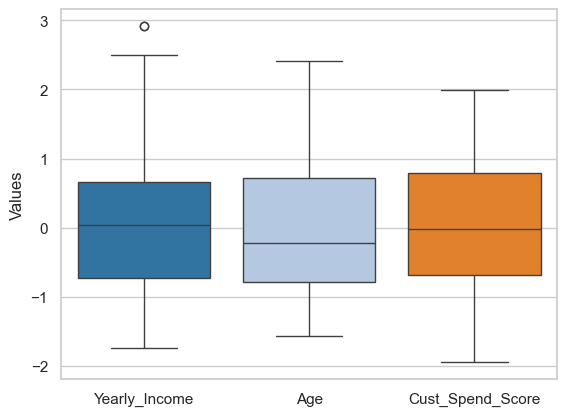

In [88]:
## Checking for Outliers
sns.set(style='whitegrid')
sns.boxplot(data=cust_scaled, palette='tab20')
plt.ylabel("Values")


In [89]:
# There is outlier in Variable Yearly_Income

In [91]:
## Outlier Treatment

def remove_outlier(col):
    Q1,Q3 = np.percentile(col, [25,75])
    IQR = Q3-Q1
    lower_range = Q1-(1.5*IQR)
    upper_range = Q3+(1.5*IQR)
    return lower_range, upper_range

In [94]:
for col in cust_scaled.columns:
    lr,ur = remove_outlier(cust_scaled[col])
    cust_scaled[col] = np.where(cust_scaled[col]>ur, ur, cust_scaled[col])
    cust_scaled[col] = np.where(cust_scaled[col]<lr, lr, cust_scaled[col])

Text(0, 0.5, 'Values')

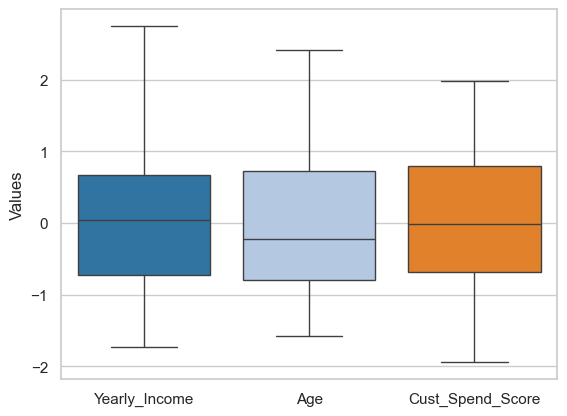

In [95]:
## Post Outlier Treatment
sns.set(style='whitegrid')
sns.boxplot(data=cust_scaled, palette='tab20')
plt.ylabel("Values")

In [96]:
# Now the outliers have been treated

In [97]:
cust_scaled.head()

,Yearly_Income,Age,Cust_Spend_Score
0,-1.738999,-1.501068,-0.284181
1,-1.738999,-1.501068,1.063563
2,-1.700830,-1.145280,-1.670433
3,-1.700830,-1.002965,1.063563
4,-1.662660,-0.504863,-0.399702


In [ ]:
Xc = cust_scaled

In [101]:
from sklearn.cluster import KMeans

wcss =[]

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


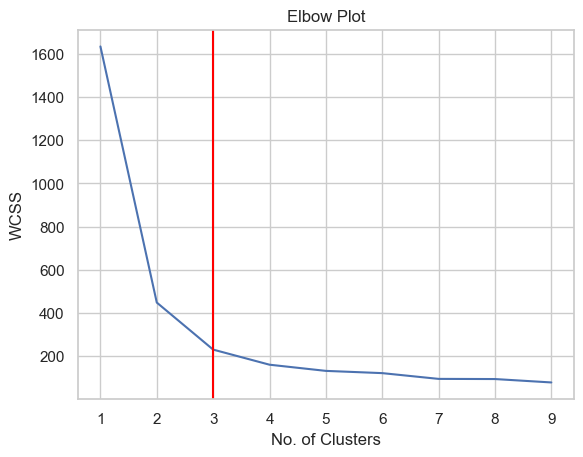

In [103]:
# Elbow Plot
plt.plot(range(1,10), wcss)
plt.axvline(x=3, color='red')
plt.title("Elbow Plot")
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# Optimal Value of k = 3 

In [108]:
# Creating 3 Clusters
kms_new_cluster = KMeans(n_clusters=3, random_state=42)

kms_new_cluster.fit(X)

cust_scaled['Cluster'] = pd.Series(kms_new_cluster.labels_)


In [109]:
cust_scaled.head()

,Yearly_Income,Age,Cust_Spend_Score,Cluster
0,-1.738999,-1.501068,-0.284181,2
1,-1.738999,-1.501068,1.063563,2
2,-1.700830,-1.145280,-1.670433,1
3,-1.700830,-1.002965,1.063563,1
4,-1.662660,-0.504863,-0.399702,0


In [116]:
# Silhouette Coefficient
from sklearn.metrics import silhouette_score 

num_clusters = [2,3,4,5]

for k in num_clusters:
    kmns = KMeans(n_clusters=k, random_state=42)
    predict = kmns.fit_predict(X)
    score = silhouette_score(X, predict, random_state=42)
    print ("For {} clusters the silhouette score is {})".format(k, score))

For 2 clusters the silhouette score is 0.6086696658146895)
For 3 clusters the silhouette score is 0.5199710683848234)
For 4 clusters the silhouette score is 0.473750846616801)
For 5 clusters the silhouette score is 0.4281760685778925)


In [ ]:
# Maximum value of silhouette score is for k=3